In [1]:
import statsmodels.formula.api as smf
import pandas as pd
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import io
import numpy as np

df = pd.read_csv("/Users/inecuypers/Documents/DTA thesis/finals/df_sentiment_emotion_final.csv", index_col=0)
df.head(1)

,id,streamer,message,emotes,gender,age,genre,unique_emotes,total_emotes,sentiment,...,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
0,6b9fd713-82dc-4f76-90b3-a7d2f006e1ac,annacramling,Gg CoolCat,CoolCat,female,genz,nongaming,1,1,2,...,False,False,False,True,False,True,False,False,False,True


In [2]:
# 1. Convert strings to lists of emotes
df['emote_list'] = df['emotes'].fillna('').apply(lambda x: [e.strip() for e in str(x).split(',') if e.strip()])
#print(df['emote_list'])

# 3. Find Top 5 by MESSAGE APPEARANCE (Presence)
presence_emotes = [emote for sublist in df['emote_list'] for emote in set(sublist)]
#print(presence_emotes)
top_5_presence = pd.Series(presence_emotes).value_counts().head(5)

print("\nTop 5 Message Appearance:\n", top_5_presence)


Top 5 Message Appearance:
 LUL      841
<3       422
:)       240
Kappa    175
:D       141
Name: count, dtype: int64


In [3]:
# ensure categorical variables
df["gender"] = df["gender"].astype("category")
df["age"] = df["age"].astype("category")
df["genre"] = df["genre"].astype("category")
df['streamer'] = df['streamer'].astype('category').cat.codes
df["sentiment"] = df["sentiment"].map({
    0: 0,
    2: 1
})

emotion_cols = [
    "anger", "disgust", "fear", "joy", "love", "optimism", "pessimism", "sadness", "surprise", "trust",
]

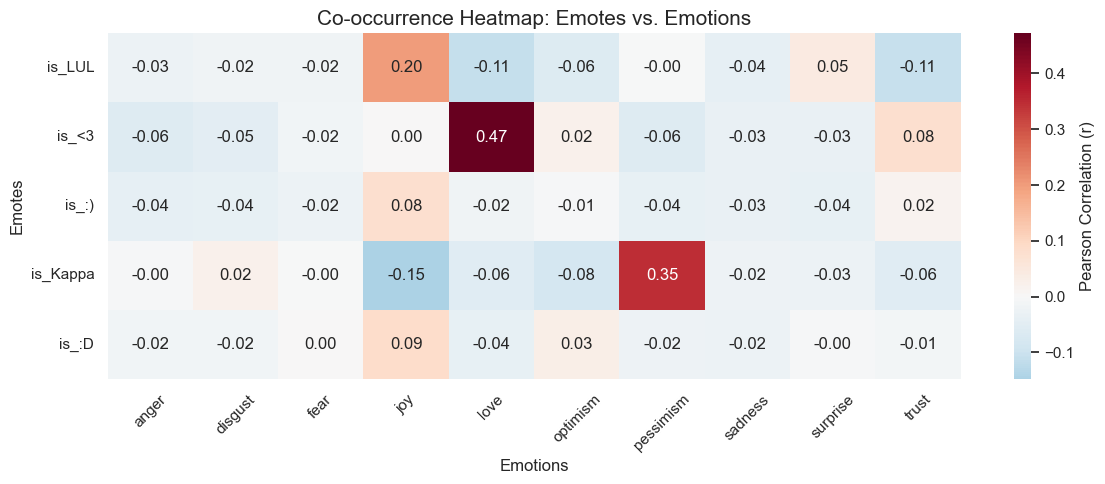

In [4]:
target_emotes = top_5_presence.index.tolist()

# Calculate correlation between emote presence and the 12 emotion columns
# 2. Create binary columns for your top emotes if they don't exist
for emote in target_emotes:
    df[f'is_{emote}'] = df['emote_list'].apply(lambda x: 1 if emote in x else 0)

emote_cols = [f'is_{emote}' for emote in target_emotes]

# 3. Calculate the Correlation Matrix
# We only care about the correlation BETWEEN emotions and emotes
corr_matrix = df[emotion_cols + emote_cols].corr()

# 4. Subset the matrix so Emotes are on one axis and Emotions on the other
# This prevents a giant square and gives you a readable rectangle
subset_corr = corr_matrix.loc[emote_cols, emotion_cols]

# 5. Plot
plt.figure(figsize=(12, 5))
sns.set_theme(style="white")

# 'RdBu_r' is a standard diverging palette: Blue is positive, Red is negative
sns.heatmap(subset_corr, 
            annot=True,       # Show the correlation numbers
            fmt=".2f",        # Round to 2 decimals
            cmap="RdBu_r",    # Red-Blue diverging color map
            center=0,         # Ensure 0 is the neutral color (white)
            cbar_kws={'label': 'Pearson Correlation (r)'})

plt.title("Co-occurrence Heatmap: Emotes vs. Emotions", fontsize=15)
plt.xlabel("Emotions", fontsize=12)
plt.ylabel("Emotes", fontsize=12)

# Rotate labels so they don't overlap
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# great > 0.3
# 0.3 > 0.1 decent
# weak < 0.1

In [5]:
# Assuming 'subset_corr' is the matrix we created for the heatmap
# (Emotes on index, Emotions on columns)

print("--- Strongest Emotion Associations per Emote ---")

for emote in subset_corr.index:
    # Get correlations for this specific emote
    corrs = subset_corr.loc[emote].sort_values(ascending=False)
    
    top_emotion = corrs.index[0]
    top_val = corrs.iloc[0]
    
    bottom_emotion = corrs.index[-1]
    bottom_val = corrs.iloc[-1]
    
    print(f"\nEmote: {emote}")
    print(f"  Strongest Positive: {top_emotion} ({top_val:.3f})")
    print(f"  Strongest Negative: {bottom_emotion} ({bottom_val:.3f})")
    
    # Optional: Find 'significant' ones (e.g., > 0.1 or < -0.1)
    notable = corrs[abs(corrs) > 0.1]
    print(f"  Notable associations: {notable.index.tolist()}")

--- Strongest Emotion Associations per Emote ---

Emote: is_LUL
  Strongest Positive: joy (0.203)
  Strongest Negative: love (-0.113)
  Notable associations: ['joy', 'trust', 'love']

Emote: is_<3
  Strongest Positive: love (0.472)
  Strongest Negative: anger (-0.059)
  Notable associations: ['love']

Emote: is_:)
  Strongest Positive: joy (0.082)
  Strongest Negative: anger (-0.040)
  Notable associations: []

Emote: is_Kappa
  Strongest Positive: pessimism (0.347)
  Strongest Negative: joy (-0.148)
  Notable associations: ['pessimism', 'joy']

Emote: is_:D
  Strongest Positive: joy (0.086)
  Strongest Negative: love (-0.039)
  Notable associations: []


In [9]:
# Number of top emotions to test separately for each emote
top_n = 2  

for emote in target_emotes:
    # 1. Prepare dependent variable
    df['target_present'] = df['emote_list'].apply(lambda x: 1 if emote in x else 0)
    
    # 2. Find the top N correlated emotions for THIS emote
    correlations = df[emotion_cols].corrwith(df['target_present']).abs()
    top_emotions = correlations.sort_values(ascending=False).head(top_n).index.tolist()
    
    # 3. Inner Loop: Run a separate model for EACH of the top emotions
    for emotion in top_emotions:
        # Ensure the emotion data is numeric (0/1) to prevent the Boolean subtraction error
        df[emotion] = df[emotion].astype(float)
        # Build formula for ONE emotion at a time
        formula = f"target_present ~ {emotion} * gender * age * genre"
        
        # Create a specific safe name for saving files (e.g., LUL_joy)
        # Replacing emote characters for filename safety
        safe_emote = emote.replace("<3", "heart").replace(":)", "smile").replace(":(", "sad")
        model_id = f"{safe_emote}_{emotion}"
        
        print(f"\n Running Separate Model: {emote} with {emotion}")
        
        try:
            model = smf.logit(formula, data=df)
            results = model.fit(method='bfgs', maxiter=500, 
                                cov_type='cluster', 
                                cov_kwds={'groups': df['streamer']}, 
                                disp=0)
            
            print(f" Converged: {model_id} | AIC: {results.aic:.2f}")
            print(results.summary())
            odds_ratios = np.exp(results.params)
            print(f"Odds Ratios for {emote}:\n", odds_ratios)

            # --- A. Save LaTeX Table ---
            # Using the unique model_id so files don't overwrite each other
            html_table = results.summary().tables[1].as_html()
            res_df = pd.read_html(io.StringIO(html_table), header=0, index_col=0)[0]
            res_df.index = [str(ind).replace(":", " x ") for ind in res_df.index]
            res_df.to_latex(f"table_emotion_{model_id}.tex", escape=False)

            # --- B. Create Marginal Effects Plot ---
            # Create grid for the single emotion in this specific model
            # We use 0.25 and 0.75 quantiles or 0 and 1 to show the "emotion effect"
            demographics = df[['gender', 'age', 'genre']].drop_duplicates()
            
            # Create a 'low emotion' and 'high emotion' comparison
            grid_low = demographics.copy()
            grid_low[emotion] = df[emotion].quantile(0.25) # "Weak" emotional signal
            
            grid_high = demographics.copy()
            grid_high[emotion] = df[emotion].quantile(0.75) # "Strong" emotional signal
            
            prediction_grid = pd.concat([grid_low, grid_high])
            prediction_grid['prob'] = results.predict(prediction_grid)
            prediction_grid['Intensity'] = prediction_grid[emotion].apply(
                lambda x: 'High' if x > df[emotion].median() else 'Low'
            )

            # Visualize
            g = sns.catplot(
                data=prediction_grid, x="gender", y="prob", hue="Intensity",
                col="genre", row="age", kind="point", height=4, aspect=1
            )
            g.fig.suptitle(f"Effect of {emotion} on {emote} Presence", y=1.02)
            plt.savefig(f"plot_emotion_{model_id}.png", dpi=300, bbox_inches='tight')
            plt.close('all')

        except Exception as e:
            print(f" Failed for {model_id}: {e}")


 Running Separate Model: LUL with joy
 Converged: LUL_joy | AIC: 5038.36
                           Logit Regression Results                           
Dep. Variable:         target_present   No. Observations:                 9600
Model:                          Logit   Df Residuals:                     9584
Method:                           MLE   Df Model:                           15
Date:                Mon, 22 Jun 2026   Pseudo R-squ.:                  0.1219
Time:                        14:34:45   Log-Likelihood:                -2503.2
converged:                       True   LL-Null:                       -2850.8
Covariance Type:              cluster   LLR p-value:                1.904e-138
                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                     